<a href="https://colab.research.google.com/github/prometricas/Peajes_Laura_Toro/blob/main/ML_Peajes_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Cargar base de datos**

Cargo la base desde Google Colab, convierto la fecha y dejo el DataFrame principal listo. Ordeno la información en sentido temporal para que el resto del cuaderno respete la secuencia de la serie.


In [6]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(io.BytesIO(uploaded[file_name]), engine="openpyxl")
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

print(f"Archivo cargado: {file_name}")
print(f"Dimensión de la base: {df.shape}")
print("\nColumnas disponibles:")
print(df.columns.tolist())
display(df.head())

Saving final_df.xlsx to final_df (1).xlsx
Archivo cargado: final_df (1).xlsx
Dimensión de la base: (365, 20)

Columnas disponibles:
['fecha', 'dia_semana', 'recaudo', 'movimientos', 'es_imputado', 'ACPM', 'GMC', 'GME', 'festivo_colombia', 'puente_festivo', 'semana_santa', 'vacaciones_mitad_ano', 'receso_octubre', 'temporada_fin_de_ano', 'lluvia_mm', 'horas_lluvia', 'temp_media_c', 'temp_max_c', 'temp_min_c', 'y_log']


,fecha,dia_semana,recaudo,movimientos,es_imputado,ACPM,GMC,GME,festivo_colombia,puente_festivo,semana_santa,vacaciones_mitad_ano,receso_octubre,temporada_fin_de_ano,lluvia_mm,horas_lluvia,temp_media_c,temp_max_c,temp_min_c,y_log
0,2025-01-01,Miercoles,157445700,9354,False,10883.408542,16869.106302,21036.597701,1,0,0,0,0,0,13.5,10,19.3,26.1,15.5,18.874591
1,2025-01-02,Jueves,261963000,12695,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0,10.0,6,19.6,26.3,16.0,19.383714
2,2025-01-03,Viernes,276621800,13199,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0,8.8,12,19.0,23.4,15.6,19.438162
3,2025-01-04,Sabado,259619200,13586,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0,19.4,17,19.5,25.7,15.5,19.374727
4,2025-01-05,Domingo,226524800,12264,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0,20.2,13,19.6,25.3,16.4,19.238365


# **2. Preparar  base para modelación temporal con scikit-learn y statsmodels**

Conservo la lógica del proyecto, evito fuga de información, creo variables útiles de calendario, agrego rezagos y promedios móviles del recaudo, y dejo listas la matriz de entrada, # la partición temporal, los folds y los preprocesadores para la comparación de modelos.


In [7]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

base = df.copy()
base["fecha"] = pd.to_datetime(base["fecha"])
base = base.sort_values("fecha").reset_index(drop=True)

binary_cols = [
    "es_imputado",
    "festivo_colombia",
    "puente_festivo",
    "semana_santa",
    "vacaciones_mitad_ano",
    "receso_octubre",
    "temporada_fin_de_ano",
]

for col in binary_cols:
    if col in base.columns:
        base[col] = base[col].astype(int)

base["dow_num"] = base["fecha"].dt.dayofweek
base["mes_num"] = base["fecha"].dt.month
base["dia_mes"] = base["fecha"].dt.day
base["dia_anio"] = base["fecha"].dt.dayofyear
base["semana_anio"] = base["fecha"].dt.isocalendar().week.astype(int)
base["trimestre"] = base["fecha"].dt.quarter
base["es_fin_semana"] = (base["dow_num"] >= 5).astype(int)
base["es_fin_mes"] = base["fecha"].dt.is_month_end.astype(int)
base["es_inicio_mes"] = base["fecha"].dt.is_month_start.astype(int)

base["dow_sin"] = np.sin(2 * np.pi * base["dow_num"] / 7)
base["dow_cos"] = np.cos(2 * np.pi * base["dow_num"] / 7)
base["mes_sin"] = np.sin(2 * np.pi * base["mes_num"] / 12)
base["mes_cos"] = np.cos(2 * np.pi * base["mes_num"] / 12)
base["dia_anio_sin"] = np.sin(2 * np.pi * base["dia_anio"] / 365.25)
base["dia_anio_cos"] = np.cos(2 * np.pi * base["dia_anio"] / 365.25)

for lag in [1, 7, 14, 28]:
    base[f"recaudo_lag_{lag}"] = base["recaudo"].shift(lag)

for win in [7, 14, 28]:
    base[f"recaudo_roll_mean_{win}"] = base["recaudo"].shift(1).rolling(win).mean()
    base[f"recaudo_roll_std_{win}"] = base["recaudo"].shift(1).rolling(win).std()

for lag in [1, 7]:
    base[f"movimientos_lag_{lag}"] = base["movimientos"].shift(lag)

if {"ACPM", "GMC", "GME"}.issubset(base.columns):
    base["combustible_promedio"] = base[["ACPM", "GMC", "GME"]].mean(axis=1)

if {"temp_max_c", "temp_min_c"}.issubset(base.columns):
    base["rango_termico"] = base["temp_max_c"] - base["temp_min_c"]

if {"movimientos", "festivo_colombia"}.issubset(base.columns):
    base["movimientos_x_festivo"] = base["movimientos"] * base["festivo_colombia"]

if {"movimientos", "puente_festivo"}.issubset(base.columns):
    base["movimientos_x_puente"] = base["movimientos"] * base["puente_festivo"]

if {"lluvia_mm", "horas_lluvia"}.issubset(base.columns):
    base["lluvia_x_horas_lluvia"] = base["lluvia_mm"] * base["horas_lluvia"]

target_col = "recaudo"
cols_to_drop = ["y_log", "dia_semana"]

model_df = (
    base
    .drop(columns=cols_to_drop, errors="ignore")
    .dropna()
    .reset_index(drop=True)
)

feature_cols = [col for col in model_df.columns if col not in ["fecha", target_col]]
numeric_features = feature_cols.copy()

X_full = model_df[feature_cols].copy()
y_full = model_df[target_col].copy()
fechas_modelo = model_df["fecha"].copy()

test_size = max(30, int(np.ceil(len(model_df) * 0.20)))
split_idx = len(model_df) - test_size

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

tscv = TimeSeriesSplit(n_splits=5)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    ],
    remainder="drop",
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        )
    ],
    remainder="drop",
)

print("Dimensión de la base original:", df.shape)
print("Dimensión de la base preparada:", model_df.shape)
print("Número de variables predictoras:", len(feature_cols))
print("Fecha inicial de la base preparada:", model_df["fecha"].min().date())
print("Fecha final de la base preparada:", model_df["fecha"].max().date())
print("Fecha inicial de entrenamiento:", train_df["fecha"].min().date())
print("Fecha final de entrenamiento:", train_df["fecha"].max().date())
print("Fecha inicial de prueba:", test_df["fecha"].min().date())
print("Fecha final de prueba:", test_df["fecha"].max().date())

print("\nPrimeras 20 variables predictoras:")
print(feature_cols[:20])

display(model_df.head())

Dimensión de la base original: (365, 20)
Dimensión de la base preparada: (337, 50)
Número de variables predictoras: 48
Fecha inicial de la base preparada: 2025-01-29
Fecha final de la base preparada: 2025-12-31
Fecha inicial de entrenamiento: 2025-01-29
Fecha final de entrenamiento: 2025-10-24
Fecha inicial de prueba: 2025-10-25
Fecha final de prueba: 2025-12-31

Primeras 20 variables predictoras:
['movimientos', 'es_imputado', 'ACPM', 'GMC', 'GME', 'festivo_colombia', 'puente_festivo', 'semana_santa', 'vacaciones_mitad_ano', 'receso_octubre', 'temporada_fin_de_ano', 'lluvia_mm', 'horas_lluvia', 'temp_media_c', 'temp_max_c', 'temp_min_c', 'dow_num', 'mes_num', 'dia_mes', 'dia_anio']


,fecha,recaudo,movimientos,es_imputado,ACPM,GMC,GME,festivo_colombia,puente_festivo,semana_santa,...,recaudo_roll_std_14,recaudo_roll_mean_28,recaudo_roll_std_28,movimientos_lag_1,movimientos_lag_7,combustible_promedio,rango_termico,movimientos_x_festivo,movimientos_x_puente,lluvia_x_horas_lluvia
0,2025-01-29,345943000,16016,0,10883.408542,16869.106302,21036.597701,0,0,0,...,4.154229e+07,3.012838e+08,5.678919e+07,15600.0,15948.0,16263.037515,12.0,0,0,0.0
1,2025-01-30,351164100,16111,0,10883.408542,16869.106302,21036.597701,0,0,0,...,4.171124e+07,3.080158e+08,4.985587e+07,16016.0,16336.0,16263.037515,12.7,0,0,0.4
2,2025-01-31,361141200,17186,0,10883.408542,16869.106302,21036.597701,0,0,0,...,4.184388e+07,3.112016e+08,4.965367e+07,16111.0,16976.0,16263.037515,12.5,0,0,22.0
3,2025-02-01,333386900,16786,0,10996.409910,16976.912945,21039.581395,0,0,0,...,4.121115e+07,3.142201e+08,5.004118e+07,17186.0,16483.0,16337.634750,11.3,0,0,3.6
4,2025-02-02,242964100,13831,0,10996.409910,16976.912945,21039.581395,0,0,0,...,4.122900e+07,3.168547e+08,4.899092e+07,16786.0,13059.0,16337.634750,8.8,0,0,23.2


# **3. Evaluar la estacionariedad del recaudo**
Contrasto ADF y KPSS para tener una lectura más sólida, y reviso la estructura temporal con gráficos, autocorrelación y autocorrelación parcial antes de pasar al benchmark de modelos.


Resumen de pruebas de estacionariedad:


,serie,n_obs,adf_stat,adf_pvalue,adf_lags,adf_estacionaria_5pct,kpss_stat,kpss_pvalue,kpss_lags,kpss_estacionaria_5pct,lectura_conjunta
4,recaudo_log1p_diff_1,336,-10.282691,3.743662e-18,12,True,0.389876,0.081519,274,True,Estacionaria
5,recaudo_log1p_diff_7,330,-8.770698,2.525734e-14,13,True,0.043820,0.100000,4,True,Estacionaria
3,recaudo_diff_7,330,-7.958227,2.997005e-12,13,True,0.059245,0.100000,4,True,Estacionaria
1,recaudo_log1p,337,-4.366849,3.396042e-04,15,True,0.172798,0.100000,15,True,Estacionaria
0,recaudo_nivel,337,-3.961749,1.624594e-03,15,True,0.269887,0.100000,16,True,Estacionaria
2,recaudo_diff_1,336,-10.219591,5.368325e-18,12,True,0.500000,0.041667,335,False,Resultado mixto


Serie sugerida para lectura econométrica inicial: recaudo_log1p_diff_1


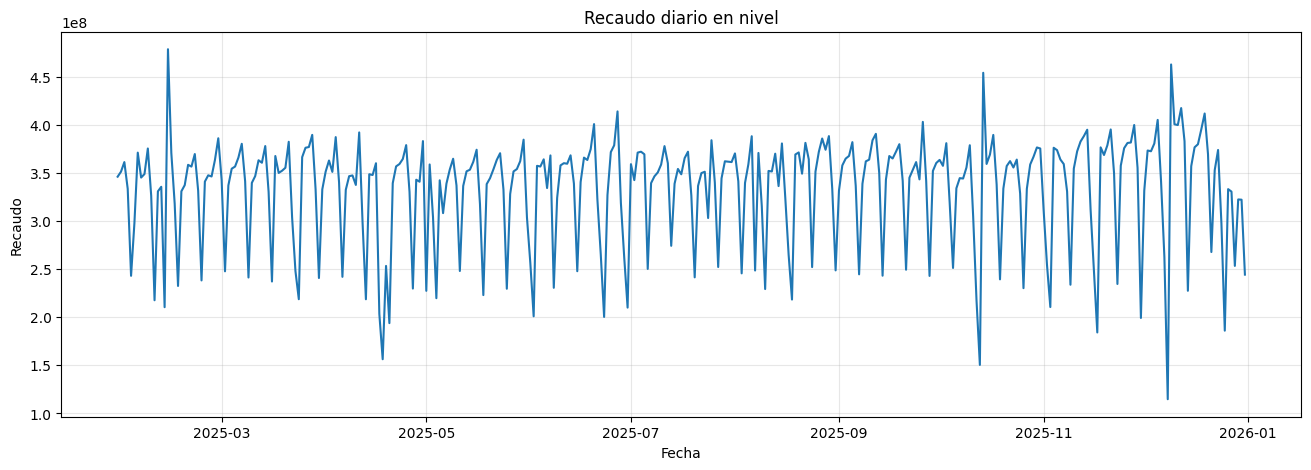

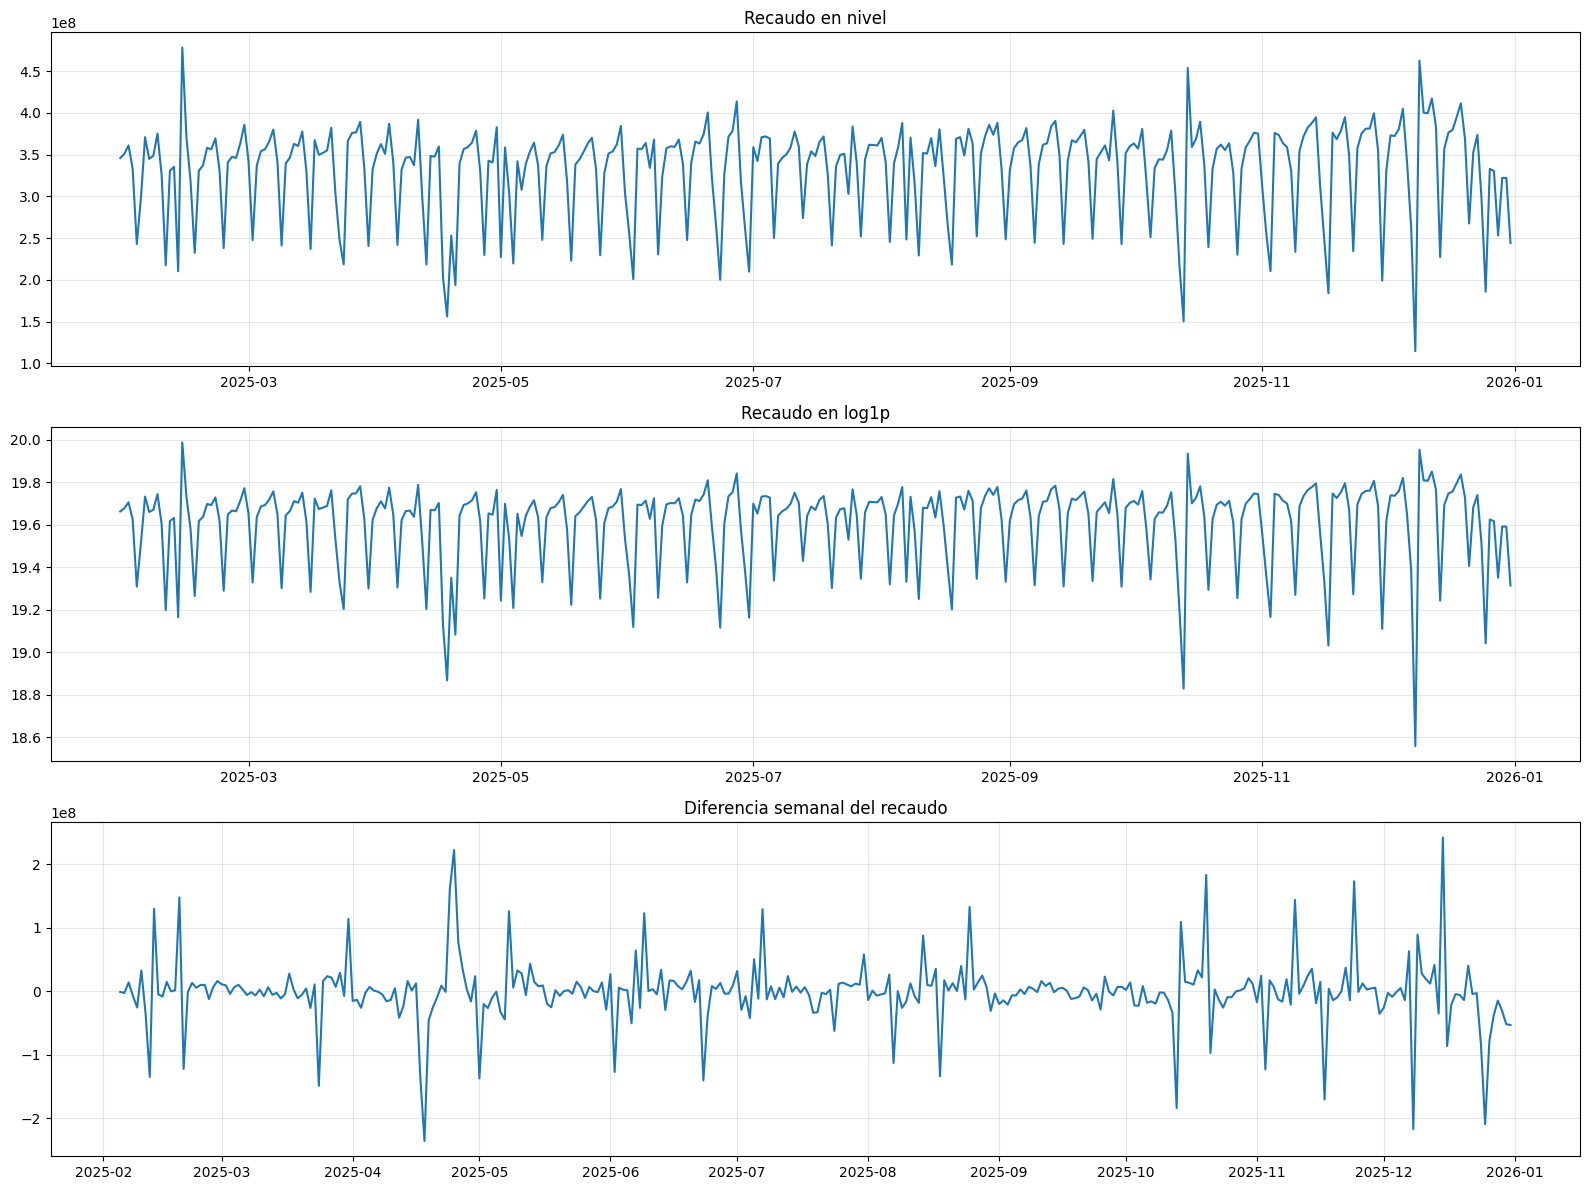

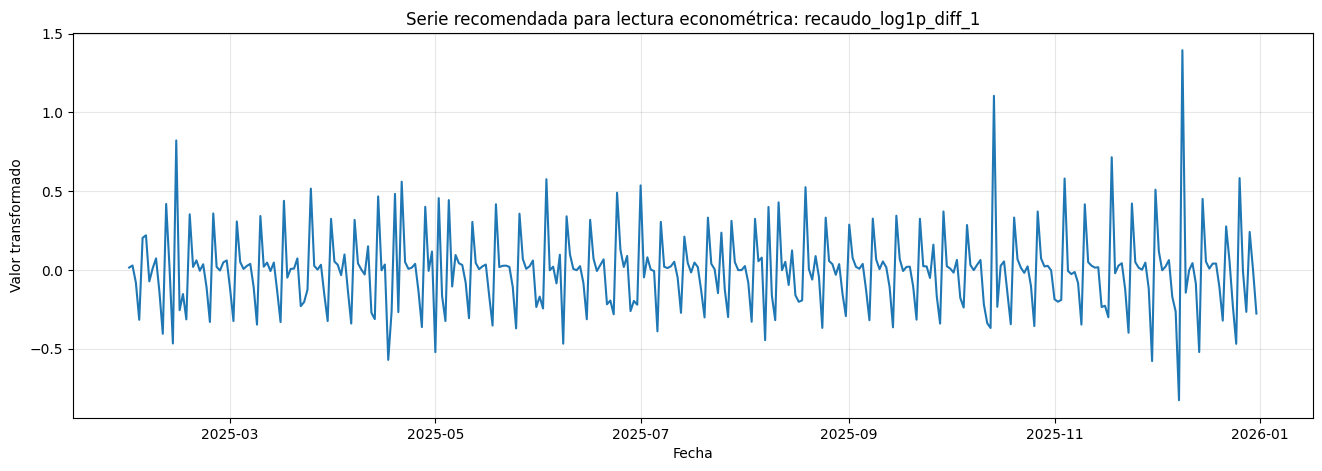

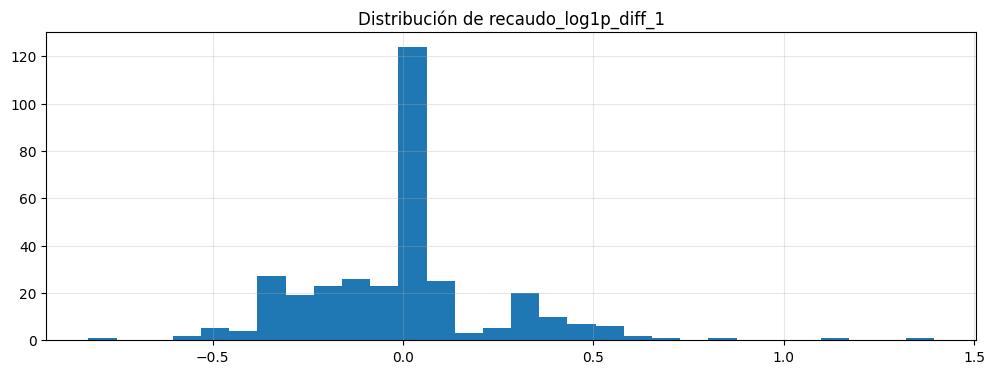

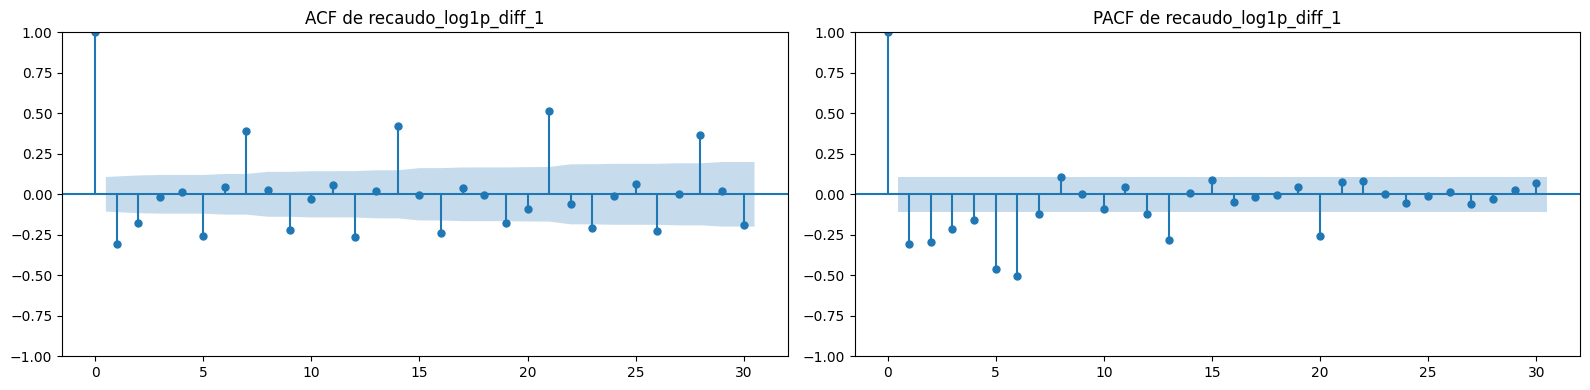

Criterio de lectura:
- ADF con p < 0.05 favorece estacionariedad.
- KPSS con p >= 0.05 favorece estacionariedad.
- Cuando ambas pruebas coinciden, la lectura es más confiable.


In [8]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

serie = model_df[["fecha", "recaudo"]].copy().set_index("fecha")["recaudo"].astype(float)

series_dict = {
    "recaudo_nivel": serie,
    "recaudo_log1p": np.log1p(serie),
    "recaudo_diff_1": serie.diff(),
    "recaudo_diff_7": serie.diff(7),
    "recaudo_log1p_diff_1": np.log1p(serie).diff(),
    "recaudo_log1p_diff_7": np.log1p(serie).diff(7),
}

def ejecutar_pruebas_estacionariedad(s, nombre):
    s = pd.Series(s).dropna().astype(float)

    resultado = {
        "serie": nombre,
        "n_obs": len(s),
        "adf_stat": np.nan,
        "adf_pvalue": np.nan,
        "adf_lags": np.nan,
        "adf_estacionaria_5pct": np.nan,
        "kpss_stat": np.nan,
        "kpss_pvalue": np.nan,
        "kpss_lags": np.nan,
        "kpss_estacionaria_5pct": np.nan,
        "lectura_conjunta": "",
    }

    try:
        adf_res = adfuller(s, autolag="AIC")
        resultado["adf_stat"] = adf_res[0]
        resultado["adf_pvalue"] = adf_res[1]
        resultado["adf_lags"] = adf_res[2]
        resultado["adf_estacionaria_5pct"] = adf_res[1] < 0.05
    except Exception:
        pass

    try:
        kpss_res = kpss(s, regression="c", nlags="auto")
        resultado["kpss_stat"] = kpss_res[0]
        resultado["kpss_pvalue"] = kpss_res[1]
        resultado["kpss_lags"] = kpss_res[2]
        resultado["kpss_estacionaria_5pct"] = kpss_res[1] >= 0.05
    except Exception:
        pass

    adf_ok = resultado["adf_estacionaria_5pct"]
    kpss_ok = resultado["kpss_estacionaria_5pct"]

    if pd.notna(adf_ok) and pd.notna(kpss_ok):
        if adf_ok and kpss_ok:
            resultado["lectura_conjunta"] = "Estacionaria"
        elif (not adf_ok) and (not kpss_ok):
            resultado["lectura_conjunta"] = "No estacionaria"
        else:
            resultado["lectura_conjunta"] = "Resultado mixto"
    else:
        resultado["lectura_conjunta"] = "Sin lectura completa"

    return resultado

resumen_tests = pd.DataFrame(
    [ejecutar_pruebas_estacionariedad(s, nombre) for nombre, s in series_dict.items()]
).sort_values(["lectura_conjunta", "adf_pvalue", "kpss_pvalue"], na_position="last")

print("Resumen de pruebas de estacionariedad:")
display(resumen_tests)

mejor_candidata = resumen_tests.loc[
    resumen_tests["lectura_conjunta"].eq("Estacionaria")
]

if len(mejor_candidata) > 0:
    serie_recomendada = mejor_candidata.iloc[0]["serie"]
else:
    serie_recomendada = "recaudo_log1p_diff_7" if "recaudo_log1p_diff_7" in series_dict else list(series_dict.keys())[0]

print(f"Serie sugerida para lectura econométrica inicial: {serie_recomendada}")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(serie.index, serie.values)
ax.set_title("Recaudo diario en nivel")
ax.set_xlabel("Fecha")
ax.set_ylabel("Recaudo")
ax.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)
axes[0].plot(serie.index, serie.values)
axes[0].set_title("Recaudo en nivel")
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.log1p(serie).index, np.log1p(serie).values)
axes[1].set_title("Recaudo en log1p")
axes[1].grid(True, alpha=0.3)

axes[2].plot(serie.diff(7).dropna().index, serie.diff(7).dropna().values)
axes[2].set_title("Diferencia semanal del recaudo")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

serie_plot = series_dict[serie_recomendada].dropna()

fig = plt.figure(figsize=(16, 5))
plt.plot(serie_plot.index, serie_plot.values)
plt.title(f"Serie recomendada para lectura econométrica: {serie_recomendada}")
plt.xlabel("Fecha")
plt.ylabel("Valor transformado")
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(serie_plot.values, bins=30)
ax.set_title(f"Distribución de {serie_recomendada}")
ax.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(serie_plot, lags=30, ax=axes[0])
axes[0].set_title(f"ACF de {serie_recomendada}")
plot_pacf(serie_plot, lags=30, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF de {serie_recomendada}")
plt.tight_layout()
plt.show()

print("Criterio de lectura:")
print("- ADF con p < 0.05 favorece estacionariedad.")
print("- KPSS con p >= 0.05 favorece estacionariedad.")
print("- Cuando ambas pruebas coinciden, la lectura es más confiable.")

# **4. Contraste estructurado de modelos por familias**

En esta etapa se comparan modelos agrupados por familias, con el fin de evaluar no solo cuál ofrece menor error, sino también qué enfoque de modelación se adapta mejor al comportamiento del recaudo.

### 1. Modelos de referencia

Estos modelos no aprenden relaciones complejas entre variables; sirven como punto de comparación mínimo.

- **Naive último valor**: proyecta el próximo valor igual al último observado. Es una referencia básica para series con alta persistencia de corto plazo.
- **Naive semanal**: repite el valor observado siete días atrás. Resulta útil cuando existe patrón semanal.
- **Media móvil 7 días**: usa el promedio reciente como pronóstico. Suaviza ruido, pero puede perder capacidad de reacción ante cambios bruscos.

### 2. Modelos lineales y regularizados

Esta familia supone una relación aditiva entre las variables explicativas y el recaudo. Son modelos interpretables y útiles como línea base fuerte.

- **Regresión lineal**: estima una relación lineal directa entre predictores y variable objetivo.
- **Ridge**: versión regularizada que reduce la sensibilidad a multicolinealidad y coeficientes inestables.
- **Lasso**: aplica regularización que puede llevar algunos coeficientes a cero, ayudando a filtrar variables menos útiles.
- **Elastic Net**: combina la lógica de Ridge y Lasso, equilibrando estabilidad y selección de variables.

### 3. Modelos basados en proximidad o kernel

Buscan capturar relaciones no lineales sin depender de una estructura paramétrica estricta.

- **KNN**: predice a partir de observaciones cercanas en el espacio de variables.
- **SVR**: ajusta una función flexible usando kernels, útil cuando la relación entre predictores y recaudo no es puramente lineal.

### 4. Ensambles tipo bagging

Construyen múltiples árboles sobre muestras o particiones aleatorias y combinan sus resultados. Suelen ser robustos frente a ruido y no linealidades.

- **Random Forest**: promedia muchos árboles con aleatoriedad controlada para mejorar generalización.
- **Extra Trees**: introduce aún más aleatoriedad en las particiones, lo que puede reducir varianza y acelerar el aprendizaje.

### 5. Ensambles tipo boosting

Entrenan modelos secuenciales que corrigen errores previos. Suelen destacar cuando hay interacciones complejas y patrones no lineales.

- **Gradient Boosting**: ajusta árboles de forma secuencial para reducir gradualmente el error.
- **Hist Gradient Boosting**: variante más eficiente computacionalmente, adecuada para bases medianas y con buen desempeño predictivo.

La comparación se realizará con validación temporal y con énfasis en **WAPE** como métrica principal, complementada con **MAE**, **RMSE**, **MAPE**, **sMAPE** y **R²**.

In [10]:
# Comparo referencias y modelos de aprendizaje automático con validación temporal.
# Organizo el contraste por familias, priorizo WAPE como métrica principal y reduzco las salidas
# a un conjunto corto de tablas que facilite lectura profesional y no dispersa.

warnings.filterwarnings("ignore")
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom * 100

def mape_seguro(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def calcular_metricas(y_true, y_pred):
    return {
        "WAPE": wape(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape_seguro(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def naive_ultimo_valor(train_y, horizon):
    ultimo = float(train_y.iloc[-1])
    return np.repeat(ultimo, horizon)

def naive_semanal(train_y, horizon, lag=7):
    base = train_y.reset_index(drop=True).copy()
    preds = []
    for i in range(horizon):
        idx = len(base) - lag + i
        if idx < len(base):
            preds.append(float(base.iloc[idx]))
        else:
            preds.append(float(preds[i - lag]))
    return np.array(preds, dtype=float)

def media_movil(train_y, horizon, ventana=7):
    valor = float(train_y.tail(ventana).mean())
    return np.repeat(valor, horizon)

def evaluar_naives_cv(train_series, n_splits=5):
    filas = []
    cv_local = TimeSeriesSplit(n_splits=n_splits)
    serie = train_series.reset_index(drop=True).copy()

    for fold, (tr_idx, val_idx) in enumerate(cv_local.split(serie), start=1):
        y_tr = serie.iloc[tr_idx].copy()
        y_val = serie.iloc[val_idx].copy()

        candidatos = {
            "Naive último valor": naive_ultimo_valor(y_tr, len(y_val)),
            "Naive semanal": naive_semanal(y_tr, len(y_val), lag=7),
            "Media móvil 7 días": media_movil(y_tr, len(y_val), ventana=7),
        }

        for nombre, pred in candidatos.items():
            fila = {"fold": fold, "modelo": nombre}
            fila.update(calcular_metricas(y_val, pred))
            filas.append(fila)

    return pd.DataFrame(filas)

def evaluar_modelo_cv(nombre, familia, pipeline_modelo, X, y, cv):
    filas = []
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X), start=1):
        X_tr = X.iloc[tr_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_val = y.iloc[val_idx].copy()

        modelo_fold = clone(pipeline_modelo)
        modelo_fold.fit(X_tr, y_tr)
        pred_val = modelo_fold.predict(X_val)

        fila = {"fold": fold, "familia": familia, "modelo": nombre}
        fila.update(calcular_metricas(y_val, pred_val))
        filas.append(fila)

    return pd.DataFrame(filas)

catalogo_modelos = [
    {
        "familia": "Referencias",
        "modelo": "Naive último valor",
        "tipo": "naive"
    },
    {
        "familia": "Referencias",
        "modelo": "Naive semanal",
        "tipo": "naive"
    },
    {
        "familia": "Referencias",
        "modelo": "Media móvil 7 días",
        "tipo": "naive"
    },
    {
        "familia": "Lineales y regularizados",
        "modelo": "Regresión lineal",
        "tipo": "ml",
        "estimador": Pipeline([
            ("prep", preprocessor_scaled),
            ("model", LinearRegression())
        ])
    },
    {
        "familia": "Lineales y regularizados",
        "modelo": "Ridge",
        "tipo": "ml",
        "estimador": Pipeline([
            ("prep", preprocessor_scaled),
            ("model", Ridge(alpha=1.0, random_state=123))
        ])
    },
    {
        "familia": "Lineales y regularizados",
        "modelo": "Lasso",
        "tipo": "ml",
        "estimador": Pipeline([
            ("prep", preprocessor_scaled),
            ("model", Lasso(alpha=0.001, random_state=123, max_iter=10000))
        ])
    },
    {
        "familia": "Lineales y regularizados",
        "modelo": "Elastic Net",
        "tipo": "ml",
        "estimador": Pipeline([
            ("prep", preprocessor_scaled),
            ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=123, max_iter=10000))
        ])
    },
    {
        "familia": "Proximidad y kernel",
        "modelo": "KNN",
        "tipo": "ml",
        "estimador": Pipeline([
            ("prep", preprocessor_scaled),
            ("model", KNeighborsRegressor(n_neighbors=7, weights="distance"))
        ])
    },
    {
        "familia": "Proximidad y kernel",
        "modelo": "SVR",
        "tipo": "ml",
        "estimador": Pipeline([
            ("prep", preprocessor_scaled),
            ("model", SVR(C=10.0, epsilon=0.1, kernel="rbf"))
        ])
    },
    {
        "familia": "Bagging y árboles aleatorios",
        "modelo": "Random Forest",
        "tipo": "ml",
        "estimador": Pipeline([
            ("prep", preprocessor_unscaled),
            ("model", RandomForestRegressor(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                random_state=123,
                n_jobs=-1
            ))
        ])
    },
    {
        "familia": "Bagging y árboles aleatorios",
        "modelo": "Extra Trees",
        "tipo": "ml",
        "estimador": Pipeline([
            ("prep", preprocessor_unscaled),
            ("model", ExtraTreesRegressor(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                random_state=123,
                n_jobs=-1
            ))
        ])
    },
    {
        "familia": "Boosting",
        "modelo": "Gradient Boosting",
        "tipo": "ml",
        "estimador": Pipeline([
            ("prep", preprocessor_unscaled),
            ("model", GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.03,
                max_depth=3,
                random_state=123
            ))
        ])
    },
    {
        "familia": "Boosting",
        "modelo": "Hist Gradient Boosting",
        "tipo": "ml",
        "estimador": Pipeline([
            ("prep", preprocessor_unscaled),
            ("model", HistGradientBoostingRegressor(
                learning_rate=0.03,
                max_depth=6,
                max_iter=400,
                min_samples_leaf=10,
                random_state=123
            ))
        ])
    },
]

# Evalúo referencias en validación temporal
cv_naive = evaluar_naives_cv(y_train, n_splits=5)
mapa_familia_naive = {
    "Naive último valor": "Referencias",
    "Naive semanal": "Referencias",
    "Media móvil 7 días": "Referencias",
}
cv_naive["familia"] = cv_naive["modelo"].map(mapa_familia_naive)

# Evalúo modelos de ML en validación temporal
cv_modelos = []
for item in catalogo_modelos:
    if item["tipo"] == "ml":
        cv_df = evaluar_modelo_cv(
            nombre=item["modelo"],
            familia=item["familia"],
            pipeline_modelo=item["estimador"],
            X=X_train,
            y=y_train,
            cv=tscv,
        )
        cv_modelos.append(cv_df)

cv_modelos = pd.concat(cv_modelos, ignore_index=True)

# Uno todos los resultados fold a fold
cv_detalle = pd.concat([cv_naive, cv_modelos], ignore_index=True)

# Resumo métricas promedio de validación temporal
leaderboard_cv = (
    cv_detalle
    .groupby(["familia", "modelo"], as_index=False)[["WAPE", "MAE", "RMSE", "MAPE", "sMAPE", "R2"]]
    .mean()
    .sort_values(["WAPE", "RMSE", "MAE"], ascending=[True, True, True])
    .reset_index(drop=True)
)

leaderboard_cv["ranking_general_cv"] = np.arange(1, len(leaderboard_cv) + 1)
leaderboard_cv["ranking_familia_cv"] = (
    leaderboard_cv
    .groupby("familia")["WAPE"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

# Armo un resumen por familia, mostrando solo el mejor modelo de cada grupo
mejor_por_familia_cv = (
    leaderboard_cv
    .sort_values(["familia", "WAPE", "RMSE", "MAE"], ascending=[True, True, True, True])
    .groupby("familia", as_index=False)
    .first()
    .sort_values("WAPE", ascending=True)
    .reset_index(drop=True)
)

mejor_por_familia_cv["ranking_entre_familias_cv"] = np.arange(1, len(mejor_por_familia_cv) + 1)

# Ajusto cada modelo sobre entrenamiento completo y evalúo en prueba final
predicciones_test = []
modelos_ajustados = {}
predicciones_guardadas = {}

for item in catalogo_modelos:
    familia = item["familia"]
    nombre = item["modelo"]

    if item["tipo"] == "naive":
        if nombre == "Naive último valor":
            pred_test = naive_ultimo_valor(y_train, len(y_test))
        elif nombre == "Naive semanal":
            pred_test = naive_semanal(y_train, len(y_test), lag=7)
        elif nombre == "Media móvil 7 días":
            pred_test = media_movil(y_train, len(y_test), ventana=7)

    else:
        modelo_fit = clone(item["estimador"])
        modelo_fit.fit(X_train, y_train)
        pred_test = modelo_fit.predict(X_test)
        modelos_ajustados[nombre] = modelo_fit

    predicciones_guardadas[nombre] = pred_test

    fila = {"familia": familia, "modelo": nombre}
    fila.update(calcular_metricas(y_test, pred_test))
    predicciones_test.append(fila)

leaderboard_test = (
    pd.DataFrame(predicciones_test)
    .sort_values(["WAPE", "RMSE", "MAE"], ascending=[True, True, True])
    .reset_index(drop=True)
)

leaderboard_test["ranking_general_test"] = np.arange(1, len(leaderboard_test) + 1)
leaderboard_test["ranking_familia_test"] = (
    leaderboard_test
    .groupby("familia")["WAPE"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

mejor_por_familia_test = (
    leaderboard_test
    .sort_values(["familia", "WAPE", "RMSE", "MAE"], ascending=[True, True, True, True])
    .groupby("familia", as_index=False)
    .first()
    .sort_values("WAPE", ascending=True)
    .reset_index(drop=True)
)

mejor_por_familia_test["ranking_entre_familias_test"] = np.arange(1, len(mejor_por_familia_test) + 1)

# Conecto validación temporal con prueba final en una tabla compacta
comparacion_final = (
    leaderboard_test
    .merge(
        leaderboard_cv[["familia", "modelo", "WAPE", "RMSE", "MAE", "ranking_general_cv", "ranking_familia_cv"]]
        .rename(columns={
            "WAPE": "WAPE_cv",
            "RMSE": "RMSE_cv",
            "MAE": "MAE_cv"
        }),
        on=["familia", "modelo"],
        how="left"
    )
    .sort_values(["WAPE", "WAPE_cv", "RMSE"], ascending=[True, True, True])
    .reset_index(drop=True)
)

mejor_modelo_cv = leaderboard_cv.iloc[0]["modelo"]
mejor_familia_cv = leaderboard_cv.iloc[0]["familia"]
mejor_modelo_test = leaderboard_test.iloc[0]["modelo"]
mejor_familia_test = leaderboard_test.iloc[0]["familia"]

print("Mejor modelo en validación temporal:")
print(f"- Familia: {mejor_familia_cv}")
print(f"- Modelo: {mejor_modelo_cv}")

print("\nMejor modelo en prueba final:")
print(f"- Familia: {mejor_familia_test}")
print(f"- Modelo: {mejor_modelo_test}")

print("\nResumen de mejores modelos por familia en validación temporal:")
display(
    mejor_por_familia_cv[
        ["ranking_entre_familias_cv", "familia", "modelo", "WAPE", "MAE", "RMSE", "MAPE", "sMAPE", "R2"]
    ]
    .style
    .format({
        "WAPE": "{:.2f}",
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "MAPE": "{:.2f}",
        "sMAPE": "{:.2f}",
        "R2": "{:.4f}",
    })
    .background_gradient(subset=["WAPE", "MAE", "RMSE", "MAPE", "sMAPE"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn")
)

print("\nLeaderboard general en prueba final:")
display(
    comparacion_final[
        [
            "ranking_general_test",
            "familia",
            "modelo",
            "ranking_familia_test",
            "WAPE",
            "MAE",
            "RMSE",
            "MAPE",
            "sMAPE",
            "R2",
            "WAPE_cv",
            "ranking_general_cv",
        ]
    ]
    .style
    .format({
        "WAPE": "{:.2f}",
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "MAPE": "{:.2f}",
        "sMAPE": "{:.2f}",
        "R2": "{:.4f}",
        "WAPE_cv": "{:.2f}",
    })
    .background_gradient(subset=["WAPE", "MAE", "RMSE", "MAPE", "sMAPE", "WAPE_cv"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn")
)

# Dejo disponibles los objetos clave para la siguiente sección
resultados_cv_detalle = cv_detalle.copy()
resultados_cv_resumen = leaderboard_cv.copy()
resultados_test_resumen = leaderboard_test.copy()
resultados_test_comparacion = comparacion_final.copy()
mejor_modelo_nombre = mejor_modelo_test

Mejor modelo en validación temporal:
- Familia: Boosting
- Modelo: Gradient Boosting

Mejor modelo en prueba final:
- Familia: Lineales y regularizados
- Modelo: Ridge

Resumen de mejores modelos por familia en validación temporal:


,ranking_entre_familias_cv,familia,modelo,WAPE,MAE,RMSE,MAPE,sMAPE,R2
0,1,Boosting,Gradient Boosting,2.75,"9,067,006","12,352,849",3.06,2.99,0.9409
1,2,Bagging y árboles aleatorios,Random Forest,2.91,"9,619,510","14,264,691",3.28,3.18,0.9232
2,3,Lineales y regularizados,Elastic Net,3.14,"10,389,110","13,868,896",3.45,3.49,0.9246
3,4,Proximidad y kernel,KNN,6.87,"22,666,793","31,986,954",8.25,7.48,0.6224
4,5,Referencias,Naive semanal,7.26,"23,976,025","41,720,700",8.60,7.84,0.3111



Leaderboard general en prueba final:


,ranking_general_test,familia,modelo,ranking_familia_test,WAPE,MAE,RMSE,MAPE,sMAPE,R2,WAPE_cv,ranking_general_cv
0,1,Lineales y regularizados,Ridge,1,3.04,"10,202,422","14,973,440",3.37,3.29,0.9511,3.66,5
1,2,Lineales y regularizados,Elastic Net,2,3.14,"10,535,953","15,275,167",3.54,3.45,0.9491,3.14,4
2,3,Lineales y regularizados,Lasso,3,3.16,"10,594,894","15,213,251",3.57,3.48,0.9495,6.39,7
3,4,Bagging y árboles aleatorios,Extra Trees,1,3.47,"11,643,002","18,236,891",4.35,4.04,0.9274,3.07,3
4,5,Boosting,Gradient Boosting,1,3.61,"12,102,664","18,652,030",4.46,4.13,0.9241,2.75,1
5,6,Bagging y árboles aleatorios,Random Forest,2,3.77,"12,640,338","19,090,006",4.71,4.34,0.9205,2.91,2
6,7,Boosting,Hist Gradient Boosting,2,3.93,"13,199,789","19,897,044",4.76,4.40,0.9136,4.23,6
7,8,Proximidad y kernel,KNN,1,7.97,"26,728,253","38,843,044",9.90,8.79,0.6708,6.87,8
8,9,Referencias,Naive semanal,1,9.61,"32,243,750","51,249,687",12.83,10.48,0.4270,7.26,9
9,10,Referencias,Naive último valor,2,14.75,"49,473,756","73,356,400",20.54,15.88,-0.1740,15.59,13


# **5. Contraste con familia econométrica SARIMAX con variables exógenas**

Evalúo una rejilla corta de especificaciones, priorizo WAPE, conservo una salida compacta y comparo el mejor SARIMAX contra el mejor modelo de aprendizaje automático y la mejor referencia.

In [13]:


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom * 100

def mape_seguro(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def calcular_metricas(y_true, y_pred):
    return {
        "WAPE": wape(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape_seguro(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

columnas_disponibles = train_df.columns.tolist()

bloque_transito = [c for c in ["movimientos"] if c in columnas_disponibles]

if "combustible_promedio" in columnas_disponibles:
    bloque_combustible = ["combustible_promedio"]
else:
    bloque_combustible = [c for c in ["ACPM", "GMC", "GME"] if c in columnas_disponibles]

bloque_clima = [c for c in ["lluvia_mm", "horas_lluvia", "temp_media_c", "rango_termico", "temp_max_c", "temp_min_c"] if c in columnas_disponibles]
bloque_clima = list(dict.fromkeys(bloque_clima))

bloque_calendario = [
    c for c in [
        "festivo_colombia",
        "puente_festivo",
        "semana_santa",
        "vacaciones_mitad_ano",
        "receso_octubre",
        "temporada_fin_de_ano",
    ] if c in columnas_disponibles
]

bloque_ciclico = [c for c in ["dow_sin", "dow_cos", "dia_anio_sin", "dia_anio_cos"] if c in columnas_disponibles]

exog_cols = list(dict.fromkeys(
    bloque_transito + bloque_combustible + bloque_clima + bloque_calendario + bloque_ciclico
))

if len(exog_cols) == 0:
    raise ValueError("No encontré variables exógenas disponibles para SARIMAX en train_df.")

y_train_sarimax = train_df["recaudo"].astype(float).copy()
y_test_sarimax = test_df["recaudo"].astype(float).copy()
X_train_sarimax = train_df[exog_cols].astype(float).copy()
X_test_sarimax = test_df[exog_cols].astype(float).copy()

candidatos_sarimax = [
    {
        "modelo": "SARIMAX 1",
        "familia": "Econométricos",
        "order": (1, 0, 1),
        "seasonal_order": (1, 1, 0, 7),
        "trend": "c",
    },
    {
        "modelo": "SARIMAX 2",
        "familia": "Econométricos",
        "order": (1, 0, 1),
        "seasonal_order": (0, 1, 1, 7),
        "trend": "c",
    },
    {
        "modelo": "SARIMAX 3",
        "familia": "Econométricos",
        "order": (2, 0, 1),
        "seasonal_order": (1, 1, 0, 7),
        "trend": "c",
    },
    {
        "modelo": "SARIMAX 4",
        "familia": "Econométricos",
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 0, 7),
        "trend": "n",
    },
    {
        "modelo": "SARIMAX 5",
        "familia": "Econométricos",
        "order": (2, 1, 1),
        "seasonal_order": (0, 1, 1, 7),
        "trend": "n",
    },
]

def ajustar_y_predecir_sarimax(y_tr, X_tr, X_future, cfg):
    modelo = SARIMAX(
        endog=y_tr,
        exog=X_tr,
        order=cfg["order"],
        seasonal_order=cfg["seasonal_order"],
        trend=cfg["trend"],
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    resultado = modelo.fit(disp=False, maxiter=200)
    pronostico = resultado.get_forecast(steps=len(X_future), exog=X_future).predicted_mean
    return np.asarray(pronostico, dtype=float), resultado

def evaluar_sarimax_cv(y, X, candidatos, n_splits=5):
    filas = []
    cv_local = TimeSeriesSplit(n_splits=n_splits)

    for cfg in candidatos:
        for fold, (tr_idx, val_idx) in enumerate(cv_local.split(X), start=1):
            y_tr = y.iloc[tr_idx].copy()
            y_val = y.iloc[val_idx].copy()
            X_tr = X.iloc[tr_idx].copy()
            X_val = X.iloc[val_idx].copy()

            try:
                pred_val, res_fit = ajustar_y_predecir_sarimax(y_tr, X_tr, X_val, cfg)
                fila = {
                    "fold": fold,
                    "familia": cfg["familia"],
                    "modelo": cfg["modelo"],
                    "order": str(cfg["order"]),
                    "seasonal_order": str(cfg["seasonal_order"]),
                    "trend": cfg["trend"],
                    "AIC": res_fit.aic,
                }
                fila.update(calcular_metricas(y_val, pred_val))
                filas.append(fila)
            except Exception as e:
                fila = {
                    "fold": fold,
                    "familia": cfg["familia"],
                    "modelo": cfg["modelo"],
                    "order": str(cfg["order"]),
                    "seasonal_order": str(cfg["seasonal_order"]),
                    "trend": cfg["trend"],
                    "AIC": np.nan,
                    "WAPE": np.nan,
                    "MAE": np.nan,
                    "RMSE": np.nan,
                    "MAPE": np.nan,
                    "sMAPE": np.nan,
                    "R2": np.nan,
                    "error": str(e),
                }
                filas.append(fila)

    return pd.DataFrame(filas)

sarimax_cv_detalle = evaluar_sarimax_cv(
    y=y_train_sarimax,
    X=X_train_sarimax,
    candidatos=candidatos_sarimax,
    n_splits=5,
)

sarimax_cv_resumen = (
    sarimax_cv_detalle
    .groupby(["familia", "modelo", "order", "seasonal_order", "trend"], as_index=False)[["AIC", "WAPE", "MAE", "RMSE", "MAPE", "sMAPE", "R2"]]
    .mean()
    .rename(columns={"AIC": "AIC_promedio"})
    .sort_values(["WAPE", "RMSE", "MAE"], ascending=[True, True, True])
    .reset_index(drop=True)
)

sarimax_cv_resumen["ranking_sarimax_cv"] = np.arange(1, len(sarimax_cv_resumen) + 1)

mejor_cfg_nombre = sarimax_cv_resumen.iloc[0]["modelo"]
mejor_cfg_order = eval(sarimax_cv_resumen.iloc[0]["order"])
mejor_cfg_seasonal = eval(sarimax_cv_resumen.iloc[0]["seasonal_order"])
mejor_cfg_trend = sarimax_cv_resumen.iloc[0]["trend"]

mejor_cfg = {
    "modelo": mejor_cfg_nombre,
    "familia": "Econométricos",
    "order": mejor_cfg_order,
    "seasonal_order": mejor_cfg_seasonal,
    "trend": mejor_cfg_trend,
}

pred_test_sarimax, sarimax_best_fit = ajustar_y_predecir_sarimax(
    y_tr=y_train_sarimax,
    X_tr=X_train_sarimax,
    X_future=X_test_sarimax,
    cfg=mejor_cfg,
)

sarimax_test_resumen = pd.DataFrame([{
    "familia": "Econométricos",
    "modelo": mejor_cfg["modelo"],
    "order": str(mejor_cfg["order"]),
    "seasonal_order": str(mejor_cfg["seasonal_order"]),
    "trend": mejor_cfg["trend"],
    **calcular_metricas(y_test_sarimax, pred_test_sarimax)
}])

comparadores = []

if "resultados_test_resumen" in globals():
    mejor_ml = (
        resultados_test_resumen[resultados_test_resumen["familia"] != "Referencias"]
        .sort_values(["WAPE", "RMSE", "MAE"], ascending=[True, True, True])
        .head(1)
        .copy()
    )
    mejor_ref = (
        resultados_test_resumen[resultados_test_resumen["familia"] == "Referencias"]
        .sort_values(["WAPE", "RMSE", "MAE"], ascending=[True, True, True])
        .head(1)
        .copy()
    )

    if len(mejor_ml) > 0:
        comparadores.append(
            mejor_ml[["familia", "modelo", "WAPE", "MAE", "RMSE", "MAPE", "sMAPE", "R2"]]
        )
    if len(mejor_ref) > 0:
        comparadores.append(
            mejor_ref[["familia", "modelo", "WAPE", "MAE", "RMSE", "MAPE", "sMAPE", "R2"]]
        )

comparadores.append(
    sarimax_test_resumen[["familia", "modelo", "WAPE", "MAE", "RMSE", "MAPE", "sMAPE", "R2"]]
)

comparacion_compacta = (
    pd.concat(comparadores, ignore_index=True)
    .sort_values(["WAPE", "RMSE", "MAE"], ascending=[True, True, True])
    .reset_index(drop=True)
)

comparacion_compacta["ranking_final"] = np.arange(1, len(comparacion_compacta) + 1)

sarimax_pred_test_df = pd.DataFrame({
    "fecha": test_df["fecha"].values,
    "recaudo_real": y_test_sarimax.values,
    "recaudo_pred_sarimax": pred_test_sarimax,
})

sarimax_best_name = mejor_cfg["modelo"]
sarimax_best_order = mejor_cfg["order"]
sarimax_best_seasonal_order = mejor_cfg["seasonal_order"]
sarimax_best_trend = mejor_cfg["trend"]
sarimax_best_exog_cols = exog_cols.copy()

print("Variables exógenas seleccionadas para SARIMAX:")
print(exog_cols)

print("\nLeaderboard econométrico en validación temporal:")
display(
    sarimax_cv_resumen[
        ["ranking_sarimax_cv", "modelo", "order", "seasonal_order", "trend", "AIC_promedio", "WAPE", "MAE", "RMSE", "MAPE", "sMAPE", "R2"]
    ]
    .style
    .format({
        "AIC_promedio": "{:,.2f}",
        "WAPE": "{:.2f}",
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "MAPE": "{:.2f}",
        "sMAPE": "{:.2f}",
        "R2": "{:.4f}",
    })
    .background_gradient(subset=["AIC_promedio", "WAPE", "MAE", "RMSE", "MAPE", "sMAPE"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn")
)

print("\nComparación compacta entre la mejor referencia, el mejor modelo de aprendizaje automático y el mejor SARIMAX:")
display(
    comparacion_compacta[
        ["ranking_final", "familia", "modelo", "WAPE", "MAE", "RMSE", "MAPE", "sMAPE", "R2"]
    ]
    .style
    .format({
        "WAPE": "{:.2f}",
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "MAPE": "{:.2f}",
        "sMAPE": "{:.2f}",
        "R2": "{:.4f}",
    })
    .background_gradient(subset=["WAPE", "MAE", "RMSE", "MAPE", "sMAPE"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn")
)

Variables exógenas seleccionadas para SARIMAX:
['movimientos', 'combustible_promedio', 'lluvia_mm', 'horas_lluvia', 'temp_media_c', 'rango_termico', 'temp_max_c', 'temp_min_c', 'festivo_colombia', 'puente_festivo', 'semana_santa', 'vacaciones_mitad_ano', 'receso_octubre', 'temporada_fin_de_ano', 'dow_sin', 'dow_cos', 'dia_anio_sin', 'dia_anio_cos']

Leaderboard econométrico en validación temporal:


,ranking_sarimax_cv,modelo,order,seasonal_order,trend,AIC_promedio,WAPE,MAE,RMSE,MAPE,sMAPE,R2
0,1,SARIMAX 1,"(1, 0, 1)","(1, 1, 0, 7)",c,"4,261.07",3.28,"10,890,116","14,529,857",3.48,3.49,0.9173
1,2,SARIMAX 3,"(2, 0, 1)","(1, 1, 0, 7)",c,"4,224.86",3.31,"10,992,342","14,630,861",3.50,3.51,0.9169
2,3,SARIMAX 2,"(1, 0, 1)","(0, 1, 1, 7)",c,"4,221.96",3.36,"11,153,357","14,806,059",3.52,3.55,0.9151
3,4,SARIMAX 5,"(2, 1, 1)","(0, 1, 1, 7)",n,"4,216.09",13.88,"45,103,346","59,256,510",14.64,11.73,-1.3023
4,5,SARIMAX 4,"(1, 1, 1)","(1, 1, 0, 7)",n,"4,248.34",14.89,"48,330,448","62,656,489",15.71,12.37,-1.6368



Comparación compacta entre la mejor referencia, el mejor modelo de aprendizaje automático y el mejor SARIMAX:


,ranking_final,familia,modelo,WAPE,MAE,RMSE,MAPE,sMAPE,R2
0,1,Lineales y regularizados,Ridge,3.04,"10,202,422","14,973,440",3.37,3.29,0.9511
1,2,Econométricos,SARIMAX 1,3.74,"12,552,217","18,252,657",4.27,4.08,0.9273
2,3,Referencias,Naive semanal,9.61,"32,243,750","51,249,687",12.83,10.48,0.4270


## **5.1. Resumen del mejor SARIMAX con significancias**
Muestro primero la salida formal del modelo y después una tabla más limpia con coeficientes, # errores estándar, estadísticos z, p-valores, intervalos de confianza y estrellas de significancia.

In [12]:
from IPython.display import display

if "sarimax_best_fit" not in globals():
    raise ValueError("No encontré el objeto sarimax_best_fit. Ejecuta primero la sección 5.")

if "sarimax_best_exog_cols" in globals():
    exog_cols_ref = list(sarimax_best_exog_cols)
else:
    try:
        exog_cols_ref = list(sarimax_best_fit.model.exog_names)
    except Exception:
        exog_cols_ref = []

print("Resumen formal del mejor modelo SARIMAX:\n")
print(sarimax_best_fit.summary())

Resumen formal del mejor modelo SARIMAX:

                                     SARIMAX Results                                      
Dep. Variable:                            recaudo   No. Observations:                  269
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 7)   Log Likelihood               -4440.754
Date:                            Fri, 27 Mar 2026   AIC                           8927.508
Time:                                    00:25:36   BIC                           9008.867
Sample:                                         0   HQIC                          8960.238
                                            - 269                                         
Covariance Type:                              opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept             2.984e+05   4.37e+05      0.68

# **6. Consolidar contraste final e identificar mejor modelo global**
Muestro una tabla compacta de contendientes, comparo trayectorias reales y pronosticadas, reviso residuos del ganador y, cuando aplica, estimo la relevancia de variables del mejor modelo no econométrico.


Ranking final consolidado en prueba:


,ranking_final,familia,modelo,WAPE,MAE,RMSE,MAPE,sMAPE,R2
0,1,Lineales y regularizados,Ridge,3.04,"10,202,422","14,973,440",3.37,3.29,0.9511
1,2,Lineales y regularizados,Elastic Net,3.14,"10,535,953","15,275,167",3.54,3.45,0.9491
2,3,Lineales y regularizados,Lasso,3.16,"10,594,894","15,213,251",3.57,3.48,0.9495
3,4,Bagging y árboles aleatorios,Extra Trees,3.47,"11,643,002","18,236,891",4.35,4.04,0.9274
4,5,Boosting,Gradient Boosting,3.61,"12,102,664","18,652,030",4.46,4.13,0.9241
5,6,Econométricos,SARIMAX 1,3.74,"12,552,217","18,252,657",4.27,4.08,0.9273
6,7,Bagging y árboles aleatorios,Random Forest,3.77,"12,640,338","19,090,006",4.71,4.34,0.9205
7,8,Boosting,Hist Gradient Boosting,3.93,"13,199,789","19,897,044",4.76,4.40,0.9136
8,9,Proximidad y kernel,KNN,7.97,"26,728,253","38,843,044",9.90,8.79,0.6708
9,10,Referencias,Naive semanal,9.61,"32,243,750","51,249,687",12.83,10.48,0.4270



Mejor modelo global en prueba: Ridge | familia: Lineales y regularizados


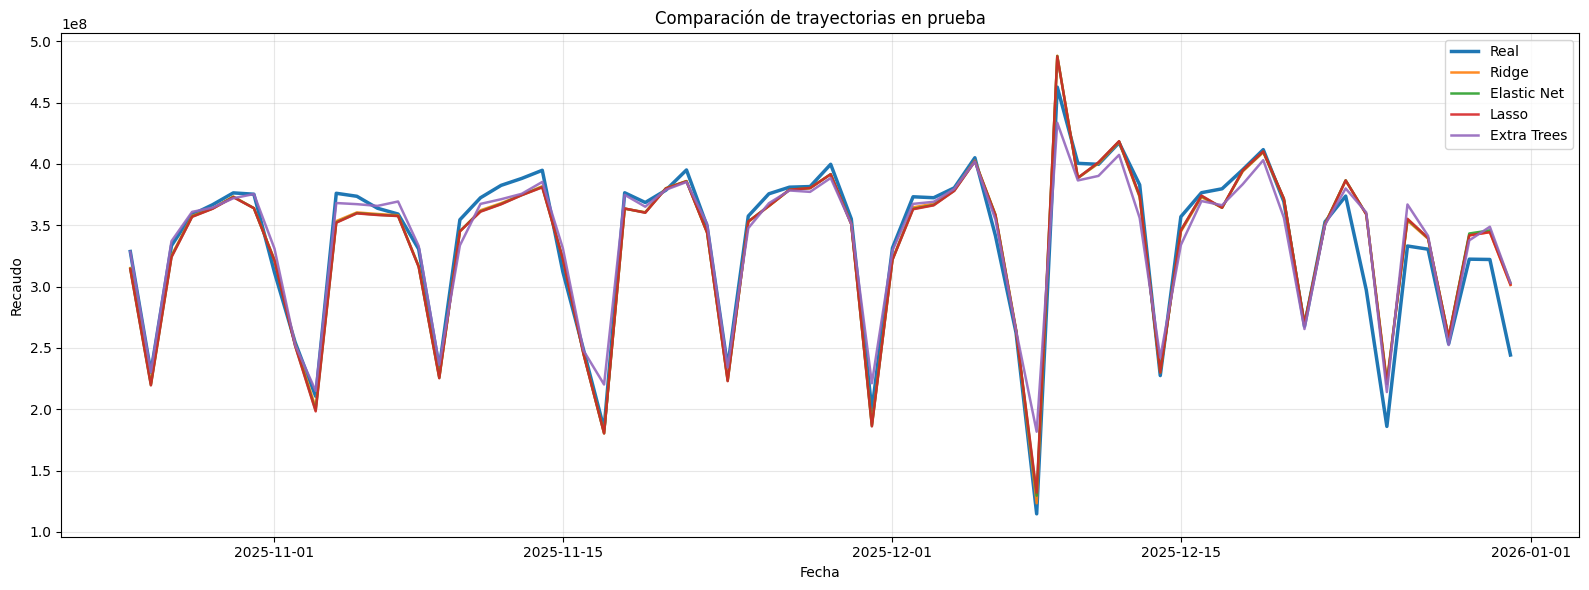

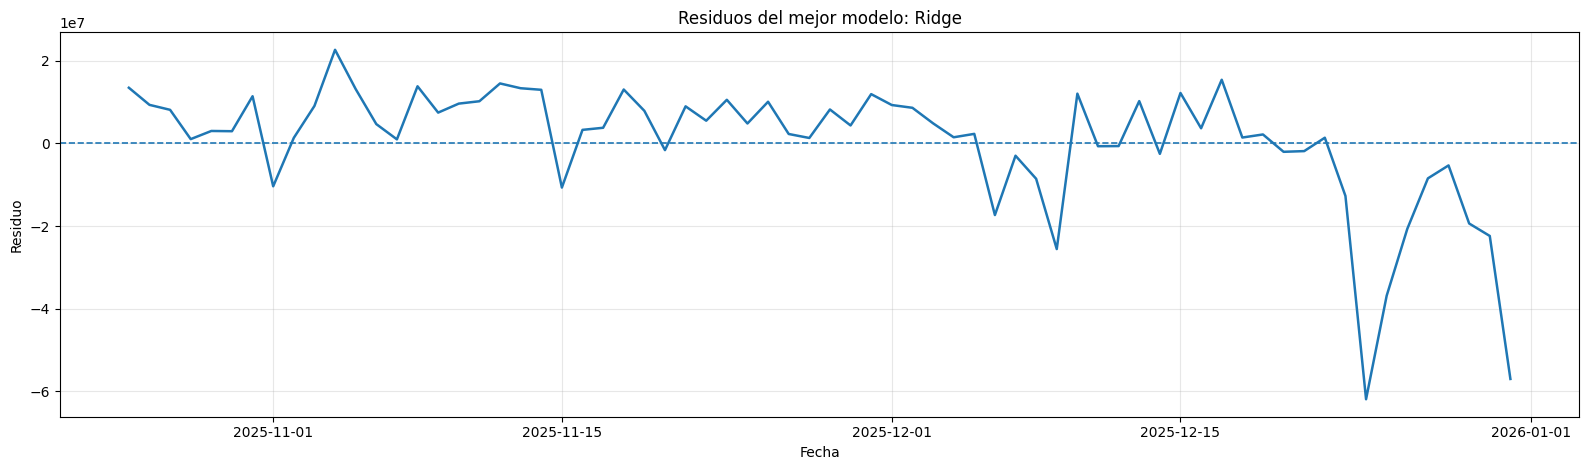

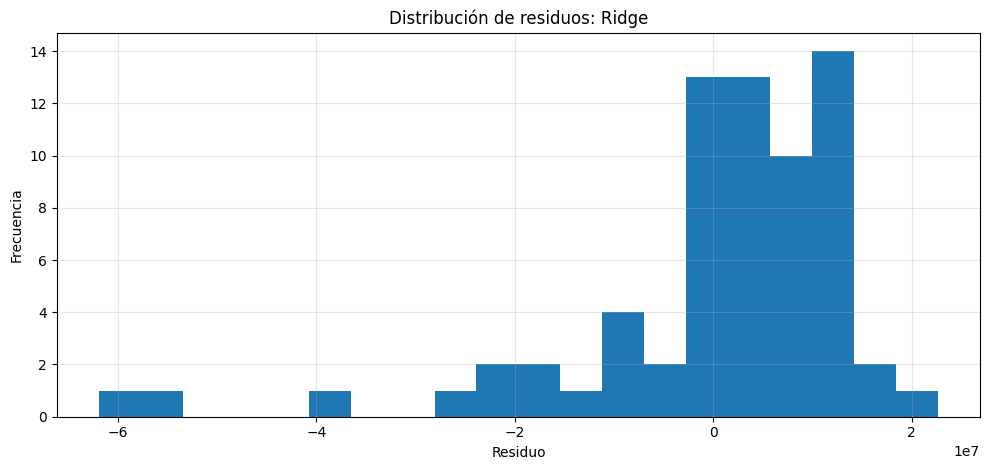

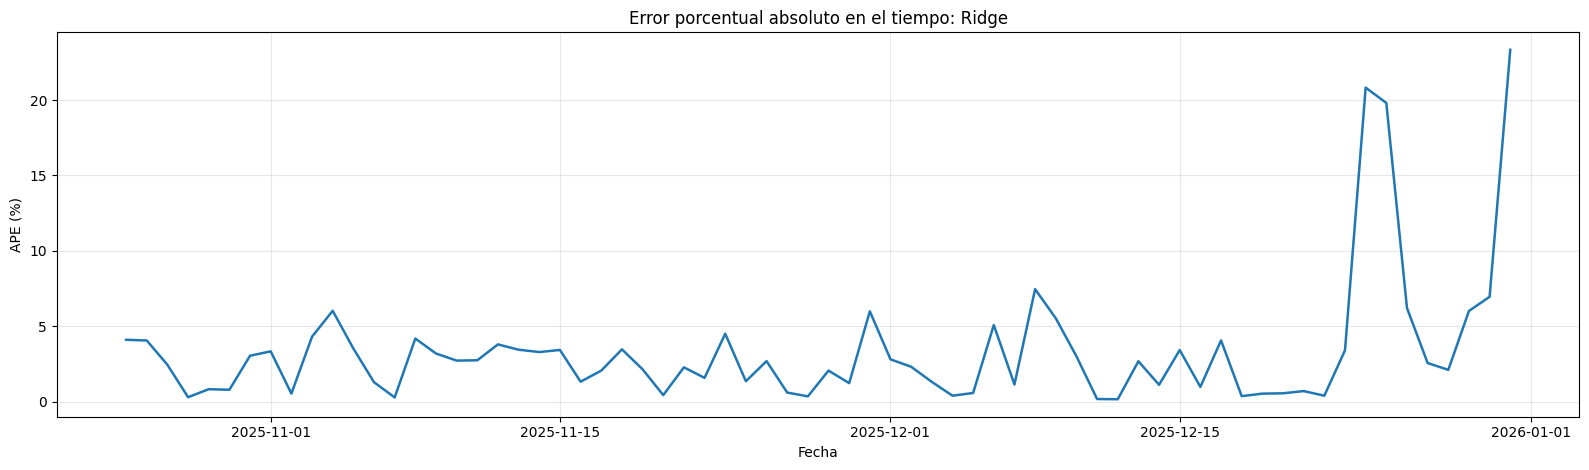

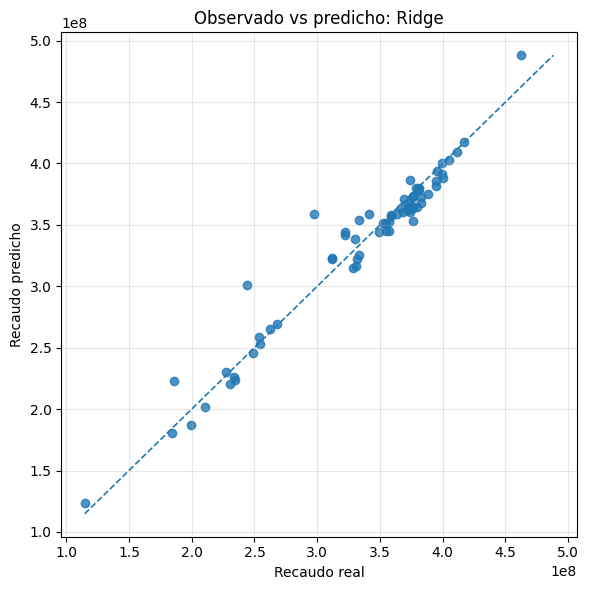


Resumen de residuos del mejor modelo:


,modelo,familia,media_residuo,mediana_residuo,desv_std_residuo,min_residuo,max_residuo,WAPE,MAPE,sMAPE
0,Ridge,Lineales y regularizados,"510,289","3,470,801","15,076,006","-61,904,284","22,650,332",3.04,3.37,3.29


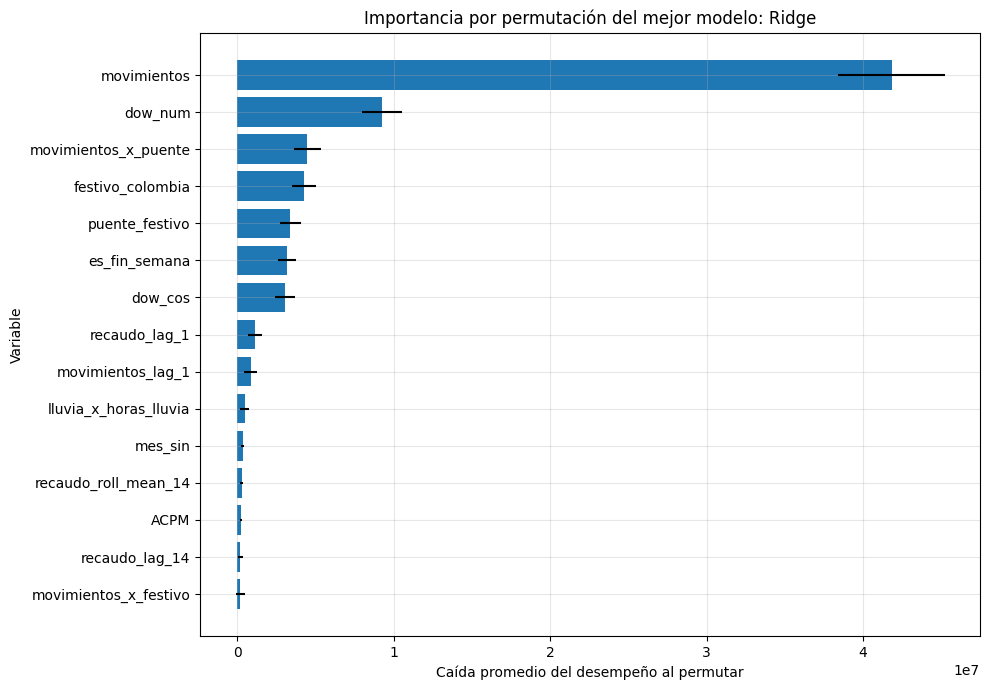


Variables más influyentes del mejor modelo no econométrico:


,variable,importancia_media,importancia_std
0,movimientos,41813466.211882,3390801.731379
1,dow_num,9265897.346952,1282208.062167
2,movimientos_x_puente,4476264.980225,865351.862971
3,festivo_colombia,4281394.163252,774263.862674
4,puente_festivo,3396426.265029,651395.616842
5,es_fin_semana,3191477.469689,583136.311946
6,dow_cos,3043200.484519,622601.479429
7,recaudo_lag_1,1116464.835594,437871.741811
8,movimientos_lag_1,851396.599014,415553.689319
9,lluvia_x_horas_lluvia,472840.705603,290021.287364


In [14]:
from sklearn.inspection import permutation_importance

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom * 100

def mape_seguro(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def calcular_metricas(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "WAPE": wape(y_true, y_pred),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
        "MAPE": mape_seguro(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "R2": 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2),
    }

if "test_df" not in globals():
    raise ValueError("No encontré test_df. Ejecuta primero las secciones previas.")
if "predicciones_guardadas" not in globals():
    raise ValueError("No encontré predicciones_guardadas. Ejecuta primero la sección 4.")

y_real = test_df["recaudo"].astype(float).values
fechas_test = pd.to_datetime(test_df["fecha"]).reset_index(drop=True)

pred_map = {}
for nombre, pred in predicciones_guardadas.items():
    pred_arr = np.asarray(pred, dtype=float)
    if len(pred_arr) == len(y_real):
        pred_map[nombre] = pred_arr

if "sarimax_pred_test_df" in globals():
    if "recaudo_pred_sarimax" in sarimax_pred_test_df.columns:
        sarimax_nombre_plot = sarimax_best_name if "sarimax_best_name" in globals() else "SARIMAX"
        pred_map[sarimax_nombre_plot] = np.asarray(sarimax_pred_test_df["recaudo_pred_sarimax"].values, dtype=float)

filas_metricas = []
familia_lookup = {}

if "resultados_test_resumen" in globals():
    for _, row in resultados_test_resumen.iterrows():
        familia_lookup[row["modelo"]] = row["familia"]

if "sarimax_best_name" in globals():
    familia_lookup[sarimax_best_name] = "Econométricos"

for nombre, pred in pred_map.items():
    fila = {
        "familia": familia_lookup.get(nombre, "No clasificada"),
        "modelo": nombre,
    }
    fila.update(calcular_metricas(y_real, pred))
    filas_metricas.append(fila)

ranking_final = (
    pd.DataFrame(filas_metricas)
    .sort_values(["WAPE", "RMSE", "MAE"], ascending=[True, True, True])
    .reset_index(drop=True)
)
ranking_final["ranking_final"] = np.arange(1, len(ranking_final) + 1)

mejor_global = ranking_final.iloc[0]["modelo"]
mejor_familia = ranking_final.iloc[0]["familia"]
pred_best = pred_map[mejor_global]

top_n = min(4, len(ranking_final))
top_modelos = ranking_final["modelo"].head(top_n).tolist()

df_plot = pd.DataFrame({
    "fecha": fechas_test,
    "recaudo_real": y_real,
})

for nombre in top_modelos:
    df_plot[f"pred_{nombre}"] = pred_map[nombre]

residuos_best = y_real - pred_best
ape_best = np.where(y_real != 0, np.abs(residuos_best) / np.abs(y_real) * 100, np.nan)

print("Ranking final consolidado en prueba:")
display(
    ranking_final[
        ["ranking_final", "familia", "modelo", "WAPE", "MAE", "RMSE", "MAPE", "sMAPE", "R2"]
    ]
    .style
    .format({
        "WAPE": "{:.2f}",
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "MAPE": "{:.2f}",
        "sMAPE": "{:.2f}",
        "R2": "{:.4f}",
    })
    .background_gradient(subset=["WAPE", "MAE", "RMSE", "MAPE", "sMAPE"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn")
)

print(f"\nMejor modelo global en prueba: {mejor_global} | familia: {mejor_familia}")

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_plot["fecha"], df_plot["recaudo_real"], label="Real", linewidth=2.5)
for nombre in top_modelos:
    ax.plot(df_plot["fecha"], df_plot[f"pred_{nombre}"], label=nombre, linewidth=1.8, alpha=0.9)
ax.set_title("Comparación de trayectorias en prueba")
ax.set_xlabel("Fecha")
ax.set_ylabel("Recaudo")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 4.8))
ax.plot(df_plot["fecha"], residuos_best, linewidth=1.8)
ax.axhline(0, linestyle="--", linewidth=1.2)
ax.set_title(f"Residuos del mejor modelo: {mejor_global}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Residuo")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.hist(residuos_best, bins=20)
ax.set_title(f"Distribución de residuos: {mejor_global}")
ax.set_xlabel("Residuo")
ax.set_ylabel("Frecuencia")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 4.8))
ax.plot(df_plot["fecha"], ape_best, linewidth=1.8)
ax.set_title(f"Error porcentual absoluto en el tiempo: {mejor_global}")
ax.set_xlabel("Fecha")
ax.set_ylabel("APE (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_real, pred_best, alpha=0.8)
min_v = min(np.min(y_real), np.min(pred_best))
max_v = max(np.max(y_real), np.max(pred_best))
ax.plot([min_v, max_v], [min_v, max_v], linestyle="--", linewidth=1.2)
ax.set_title(f"Observado vs predicho: {mejor_global}")
ax.set_xlabel("Recaudo real")
ax.set_ylabel("Recaudo predicho")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

tabla_residuos = pd.DataFrame({
    "fecha": fechas_test,
    "recaudo_real": y_real,
    "recaudo_predicho": pred_best,
    "residuo": residuos_best,
    "ape_pct": ape_best,
})

resumen_residuos = pd.DataFrame([{
    "modelo": mejor_global,
    "familia": mejor_familia,
    "media_residuo": np.mean(residuos_best),
    "mediana_residuo": np.median(residuos_best),
    "desv_std_residuo": np.std(residuos_best, ddof=1),
    "min_residuo": np.min(residuos_best),
    "max_residuo": np.max(residuos_best),
    "WAPE": wape(y_real, pred_best),
    "MAPE": mape_seguro(y_real, pred_best),
    "sMAPE": smape(y_real, pred_best),
}])

print("\nResumen de residuos del mejor modelo:")
display(
    resumen_residuos.style
    .format({
        "media_residuo": "{:,.0f}",
        "mediana_residuo": "{:,.0f}",
        "desv_std_residuo": "{:,.0f}",
        "min_residuo": "{:,.0f}",
        "max_residuo": "{:,.0f}",
        "WAPE": "{:.2f}",
        "MAPE": "{:.2f}",
        "sMAPE": "{:.2f}",
    })
    .background_gradient(subset=["WAPE", "MAPE", "sMAPE"], cmap="RdYlGn_r")
)

importancia_df = None

if mejor_global in globals().get("modelos_ajustados", {}):
    modelo_obj = modelos_ajustados[mejor_global]
    try:
        perm = permutation_importance(
            modelo_obj,
            X_test,
            y_test,
            scoring="neg_mean_absolute_error",
            n_repeats=20,
            random_state=123,
            n_jobs=-1,
        )
        importancia_df = (
            pd.DataFrame({
                "variable": X_test.columns,
                "importancia_media": perm.importances_mean,
                "importancia_std": perm.importances_std,
            })
            .sort_values("importancia_media", ascending=False)
            .reset_index(drop=True)
        )

        top_imp = importancia_df.head(15).sort_values("importancia_media", ascending=True)

        fig, ax = plt.subplots(figsize=(10, 7))
        ax.barh(top_imp["variable"], top_imp["importancia_media"], xerr=top_imp["importancia_std"])
        ax.set_title(f"Importancia por permutación del mejor modelo: {mejor_global}")
        ax.set_xlabel("Caída promedio del desempeño al permutar")
        ax.set_ylabel("Variable")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print("\nVariables más influyentes del mejor modelo no econométrico:")
        display(
            importancia_df.head(15).style
            .format({
                "importancia_media": "{:.6f}",
                "importancia_std": "{:.6f}",
            })
            .background_gradient(subset=["importancia_media"], cmap="RdYlGn")
        )
    except Exception as e:
        print(f"\nNo fue posible calcular importancia por permutación para {mejor_global}: {e}")

ranking_final_global = ranking_final.copy()
pronosticos_test_top = df_plot.copy()
residuos_mejor_modelo = tabla_residuos.copy()
importancia_mejor_modelo = importancia_df.copy() if importancia_df is not None else None
mejor_modelo_global_nombre = mejor_global
mejor_modelo_global_familia = mejor_familia